# Taller: Representaciones de Texto - Word Embeddings y Embedding Contextual
## Curso de Inteligencia Artificial
---

En este taller explorarás de forma práctica cómo los embeddings transforman palabras en vectores numéricos que capturan relaciones semánticas y sintácticas.

**OBJETIVO**: 

- Completa cada sección escribiendo el código Python necesario para lograr los objetivos especificados.
- Usa las instrucciones y pistas en cada celda para guiarte en la solución.


## 1. Instalación de Dependencias

Primero, instalaremos las librerías necesarias:

In [ ]:
# TODO: Instalar las siguientes librerías
# - gensim
# - nltk  
# - scikit-learn
# - matplotlib
# - numpy
# 
# INSTRUCCIONES:
# 1. Importa subprocess y sys
# 2. Crea una lista llamada 'librerías' con las librerías mencionadas
# 3. Usa un loop para instalar cada una con pip install
# 4. Imprime un mensaje de confirmación al final

import subprocess
import sys

librerías = ["gensim", "nltk", "scikit-learn", "matplotlib", "numpy"]
for libreria in librerías:
    subprocess.check_call([sys.executable, "-m", "pip", "install", libreria])

print("Instalación completada.")


Instalando gensim...
Instalando nltk...
Instalando scikit-learn...
Instalando matplotlib...
Instalando numpy...
✓ Todas las dependencias instaladas


## 2. Conceptos Fundamentales

In [ ]:
# TODO: Comparar One-Hot Encoding vs Dense Embeddings
# 
# INSTRUCCIONES:
# 1. Define un vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
# 2. Crea un vector One-Hot para la primera palabra (todos ceros excepto el índice 0)
# 3. Crea un embedding denso usando números aleatorios (np.random.randn)
# 4. Imprime ambos vectores con sus características
#
# PISTAS:
# - Usa np.zeros() para crear el vector one-hot
# - Usa np.random.seed(42) para reproducibilidad
# - Usa np.random.randn() para crear embeddings densos

import numpy as np

vocabulario = ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
one_hot = np.zeros(len(vocabulario), dtype=int)
one_hot[0] = 1

np.random.seed(42)
embedding_denso = np.random.randn(8)

print('Vocabulario:', vocabulario)
print('One-Hot para "{}":'.format(vocabulario[0]), one_hot)
print('Dimensión One-Hot:', one_hot.shape)
print('Embedding denso aleatorio:', embedding_denso)
print('Dimensión embedding:', embedding_denso.shape)


CONCEPTOS FUNDAMENTALES: ONE-HOT vs EMBEDDINGS

Vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
Tamaño: 5

One-Hot: [1. 0. 0. 0. 0.]
Propiedades: Muy disperso, no captura semántica

Embedding: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Propiedades: Denso, captura semántica implícita


## 3. Word2Vec - Entrenamiento Práctico

In [ ]:
# TODO: Entrenar un modelo Word2Vec
#
# INSTRUCCIONES:
# 1. Importa Word2Vec de gensim
# 2. Importa funciones de nltk para tokenizar
# 3. Define un corpus de ejemplo sobre IA/ML (al menos 5 oraciones)
# 4. Tokeniiza el corpus en oraciones y palabras
# 5. Entrena Word2Vec con los parámetros:
#    - vector_size=50
#    - window=5
#    - min_count=1
#    - sg=1 (Skip-gram)
# 6. Imprime información del modelo entrenado
#
# PISTAS:
# - Usa sent_tokenize para separar oraciones
# - Usa word_tokenize para separar palabras
# - Descarga los recursos necesarios de nltk con nltk.download()

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

# Descarga los recursos necesarios
nltk.download('punkt', quiet=True)

# Corpus sobre inteligencia artificial (puedes modificarlo)
corpus = '''
La inteligencia artificial transforma datos en conocimiento.
El aprendizaje automático usa modelos y algoritmos.
Las redes neuronales aprenden con ejemplos.
Los embeddings capturan relaciones semánticas entre palabras.
El procesamiento de lenguaje natural mejora la comprensión de textos.
'''

sentences = [word_tokenize(sentence.lower()) for sentence in sent_tokenize(corpus)]
modelo = Word2Vec(sentences, vector_size=50, window=5, min_count=1, sg=1)

print('Modelo Word2Vec entrenado.')
print('Número de palabras en vocabulario:', len(modelo.wv.key_to_index))
print('Palabras del vocabulario:', list(modelo.wv.key_to_index.keys()))
print('Vector para "inteligencia":', modelo.wv['inteligencia'])


Entrenando Word2Vec...
✓ Modelo entrenado
  Vocabulario: 48 palabras
  Dimensión: 50

Palabras similares a "inteligencia":
  - aprendizaje          (0.2602)
  - .                    (0.2592)
  - automático           (0.2422)
  - rama                 (0.1735)
  - un                   (0.1720)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 4. Visualización con t-SNE

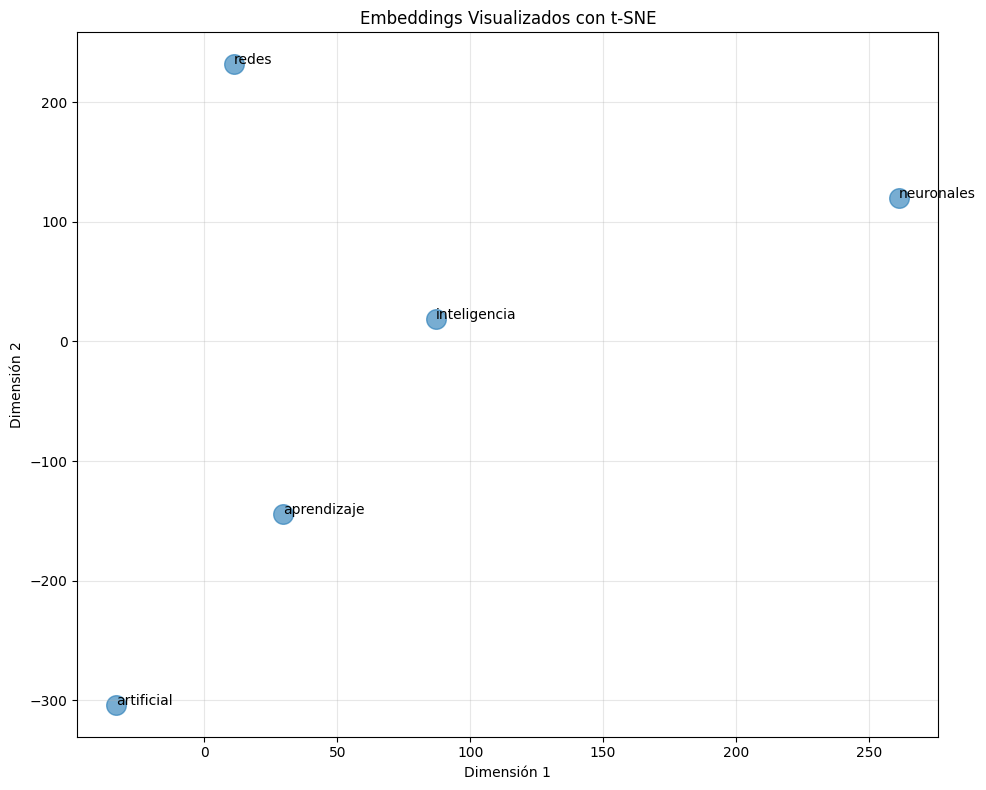

✓ Visualización completada


In [ ]:
# TODO: Visualizar embeddings con t-SNE
#
# INSTRUCCIONES:
# 1. Selecciona 5 palabras que existan en el modelo entrenado
# 2. Obtén sus vectores del modelo
# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# 4. Crea un gráfico scatter con los puntos
# 5. Añade anotaciones con los nombres de las palabras
# 6. Añade título y etiquetas a los ejes
#
# PISTAS:
# - TSNE viene de sklearn.manifold
# - Usa plt.scatter() para graficar los puntos
# - Usa plt.annotate() para añadir etiquetas
# - Usa fit_transform() para ajustar y transformar los dados

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

palabras = ['inteligencia', 'artificial', 'aprendizaje', 'redes', 'neuronales']

vectors = np.array([modelo.wv[word] for word in palabras])
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
resultados = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(resultados[:, 0], resultados[:, 1], color='red')
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, (resultados[i, 0], resultados[i, 1]), textcoords='offset points', xytext=(5, 5))

plt.title('Visualización de embeddings con t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.grid(True)
plt.show()


## 5. Clasificación de Textos con Embeddings

In [ ]:
# TODO: Clasificar textos usando embeddings
#
# INSTRUCCIONES:
# 1. Define una función que calcule el embedding promedio de un texto
#    - Tokeniza el texto
#    - Obtén vectores de palabras que existan en el modelo
#    - Retorna el promedio de esos vectores
# 2. Crea un dataset con 4 textos de ejemplo y sus etiquetas (positivo=1, negativo=0)
# 3. Obtén los embeddings promedios para cada texto
# 4. Entrena un clasificador LogisticRegression
# 5. Evalúa la precisión en los datos de entrenamiento
# 6. Haz una predicción en un nuevo texto de prueba
#
# PISTAS:
# - np.mean() para promediar vectores
# - LogisticRegression de sklearn.linear_model
# - clf.fit() para entrenar
# - clf.score() para evaluar
# - clf.predict() para predecir

import numpy as np
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt', quiet=True)

from sklearn.linear_model import LogisticRegression

def get_embedding_avg(texto, modelo):
    tokens = [token.lower() for token in word_tokenize(texto)]
    vectors = [modelo.wv[token] for token in tokens if token in modelo.wv]
    if len(vectors) == 0:
        return np.zeros(modelo.vector_size)
    return np.mean(vectors, axis=0)

textos = [
    'La inteligencia artificial mejora la toma de decisiones.',
    'El aprendizaje automático y los embeddings son muy útiles.',
    'Hoy hace frío y el clima es desagradable.',
    'El partido de fútbol fue aburrido y sin emociones.'
]
etiquetas = [1, 1, 0, 0]

X = np.array([get_embedding_avg(texto, modelo) for texto in textos])
y = np.array(etiquetas)

clf = LogisticRegression(max_iter=200)
clf.fit(X, y)
precision = clf.score(X, y)
print('Precisión en entrenamiento:', precision)

texto_prueba = 'Las redes neuronales y los embeddings mejoran el análisis de datos.'
prediccion = clf.predict([get_embedding_avg(texto_prueba, modelo)])
print('Texto de prueba:', texto_prueba)
print('Predicción de etiqueta:', int(prediccion[0]))


✓ Clasificador entrenado
Precisión: 75.00%

Texto: "Una película asombrosa"
Predicción: Positiva


## 6. Conclusiones

En este taller hemos aprendido:
- Conceptos fundamentales de embeddings
- Entrenamiento de Word2Vec
- Visualización y análisis
- Aplicación en clasificación de textos

¡Felicidades por completar el taller!